# Enterprise Financial Risk Intelligence & Fraud Forensics
## Notebook 13: Probability Calibration & Brier Score Optimization Engine

---

### Scientific Problem Formulation & Asymmetric Optimization Mathematics:

In high-stakes financial risk infrastructure, raw classification scores are insufficient. Automated fraud engines must provide **true posterior probabilities** $P(y = 1 \mid \mathbf{x})$ to accurately compute expected monetary loss:

$$\mathbb{E}[\text{Loss}_i] = P(y_i = 1 \mid \mathbf{x}_i) \cdot \text{Amount}_i$$

However, non-linear ensemble models (e.g., Gradient Boosted Decision Trees, Random Forests) and highly regularized neural networks produce severely uncalibrated probability estimates under extreme class imbalance ($578:1$). GBDTs push probabilities toward $0$ and $1$ due to greedy tree splitting, while bagging ensembles artificially compress probability tails toward the sample prior.

#### 1. Brier Score Decomposition Mathematics:
The Brier Score measures mean squared error in probability space:
$$\text{BS} = \frac{1}{N} \sum_{i=1}^N (\hat{p}_i - y_i)^2$$

According to Murphy's decomposition into $K$ confidence bins $\{B_1, \dots, B_K\}$, the Brier Score is partitioned into three orthogonal components:
$$\text{BS} = \text{Reliability} - \text{Resolution} + \text{Uncertainty}$$

$$\text{Reliability} = \sum_{k=1}^K \frac{|B_k|}{N} (\bar{p}_k - \bar{y}_k)^2$$
$$\text{Resolution} = \sum_{k=1}^K \frac{|B_k|}{N} (\bar{y}_k - \bar{y})^2, \quad \text{Uncertainty} = \bar{y}(1 - \bar{y})$$
where $\bar{p}_k = \frac{1}{|B_k|} \sum_{i \in B_k} \hat{p}_i$ is the mean predicted confidence and $\bar{y}_k = \frac{1}{|B_k|} \sum_{i \in B_k} y_i$ is the true empirical fraud rate in bin $B_k$. Perfect calibration implies $\text{Reliability} = 0$.

#### 2. Calibration Metrics:
- **Expected Calibration Error (ECE)**:
$$\text{ECE} = \sum_{b=1}^B \frac{|B_b|}{N} |\text{acc}(B_b) - \text{conf}(B_b)|$$

- **Maximum Calibration Error (MCE)**:
$$\text{MCE} = \max_{b \in \{1, \dots, B\}} |\text{acc}(B_b) - \text{conf}(B_b)|$$

#### 3. Post-Hoc Calibration Paradigms:
1. **Platt Scaling (Parametric Sigmoid Logistic Fit)**:
$$P(y = 1 \mid f) = \frac{1}{1 + \exp(A f + B)}$$
parameters $A, B \in \mathbb{R}$ are optimized via negative log-likelihood on a validation partition.

2. **Isotonic Regression (Non-Parametric Monotonic Step Fit)**:
Piecewise constant fit $\hat{m}(f)$ minimizing $\sum_{i=1}^N (y_i - \hat{m}(f_i))^2$ subject to monotonicity $\hat{m}(f_i) \le \hat{m}(f_j)$ whenever $f_i \le f_j$ using the Pair Adjacent Violators (PAV) algorithm.

3. **Beta Calibration (Heavy-Tailed Skewed Fit)**:
Logistic calibration over log-transformed probability features suited for extreme fraud distributions:
$$\ln \frac{P}{1 - P} = a \ln(p) - b \ln(1 - p) + c$$


In [9]:
from IPython.display import display
import os
import json
import warnings
import time
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    brier_score_loss,
    log_loss,
    average_precision_score,
    roc_auc_score,
    precision_recall_curve
)

try:
    from lightgbm import LGBMClassifier
    has_lgb = True
except ImportError:
    has_lgb = False

try:
    from xgboost import XGBClassifier
    has_xgb = True
except ImportError:
    has_xgb = False

try:
    from catboost import CatBoostClassifier
    has_cat = True
except ImportError:
    has_cat = False

plt.style.use('seaborn-v0_8-darkgrid' if 'seaborn-v0_8-darkgrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11
sns.set_palette('deep')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

def resolve_path(rel_path):
    candidates = [
        rel_path,
        os.path.join('..', rel_path),
        os.path.join('../..', rel_path),
        os.path.join(os.getcwd(), rel_path),
        os.path.join(os.path.dirname(os.getcwd()), rel_path)
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    for p in candidates:
        parent = os.path.dirname(p)
        if parent and os.path.exists(parent):
            return p
    return rel_path

print("Probability Calibration & Reliability Forensics Engine initialized successfully.")


Probability Calibration & Reliability Forensics Engine initialized successfully.


---
## 1. Leak-Free Partition Ingestion & Exposure Stream Setup
Ingesting the engineered feature partitions ($\mathcal{D}_{\text{train}}, \mathcal{D}_{\text{val}}, \mathcal{D}_{\text{test}}$) to train base models, fit post-hoc calibrators, and evaluate out-of-time calibration fidelity.


In [10]:
train_csv_gz = resolve_path('data/processed/train_features.csv.gz')
val_csv_gz = resolve_path('data/processed/val_features.csv.gz')
test_csv_gz = resolve_path('data/processed/test_features.csv.gz')

if os.path.exists(train_csv_gz):
    train_df = pd.read_csv(train_csv_gz, compression='gzip')
    val_df = pd.read_csv(val_csv_gz, compression='gzip')
    test_df = pd.read_csv(test_csv_gz, compression='gzip')
else:
    raw_path = resolve_path('data/raw/creditcard.parquet')
    if not os.path.exists(raw_path):
        raw_path = resolve_path('data/raw/creditcard.csv')
    raw_df = pd.read_parquet(raw_path) if raw_path.endswith('.parquet') else pd.read_csv(raw_path)
    raw_df = raw_df.sort_values(by='Time').reset_index(drop=True)
    n = len(raw_df)
    train_df = raw_df.iloc[:int(n*0.70)].copy()
    val_df = raw_df.iloc[int(n*0.70):int(n*0.85)].copy()
    test_df = raw_df.iloc[int(n*0.85):].copy()

raw_file = resolve_path('data/raw/creditcard.parquet')
if not os.path.exists(raw_file):
    raw_file = resolve_path('data/raw/creditcard.csv')
raw_all = pd.read_parquet(raw_file) if raw_file.endswith('.parquet') else pd.read_csv(raw_file)
raw_all = raw_all.sort_values(by='Time').reset_index(drop=True)

test_raw_amounts = raw_all.iloc[int(len(raw_all)*0.85):]['Amount'].values
val_raw_amounts = raw_all.iloc[int(len(raw_all)*0.70):int(len(raw_all)*0.85)]['Amount'].values

feature_cols = [c for c in train_df.columns if c != 'Class']

X_train, y_train = train_df[feature_cols].values, train_df['Class'].values
X_val, y_val = val_df[feature_cols].values, val_df['Class'].values
X_test, y_test = test_df[feature_cols].values, test_df['Class'].values

print(f"Train Feature Matrix:       {X_train.shape} (Frauds: {np.sum(y_train == 1):,})")
print(f"Validation Feature Matrix:  {X_val.shape} (Frauds: {np.sum(y_val == 1):,})")
print(f"Test Feature Matrix:        {X_test.shape} (Frauds: {np.sum(y_test == 1):,})")
print(f"OOT Test Exposure:          ${np.sum(test_raw_amounts[y_test == 1]):,.2f}")


Train Feature Matrix:       (199364, 53) (Frauds: 384)
Validation Feature Matrix:  (42721, 53) (Frauds: 56)
Test Feature Matrix:        (42722, 53) (Frauds: 52)
OOT Test Exposure:          $6,168.88


---
## 2. Expected Calibration Error (ECE) & Reliability Metrics Engine
Constructing vectorized computation functions for:
- **Expected Calibration Error (ECE)**: Frequency-weighted absolute error across confidence quantiles.
- **Maximum Calibration Error (MCE)**: Maximum single-bin deviation.
- **Brier Score Decomposition**: Reliability, Resolution, and Uncertainty.


In [11]:
def calculate_ece_mce(y_true, y_prob, n_bins=10):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    
    ece = 0.0
    mce = 0.0
    bin_stats = []
    
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = (y_prob >= bin_lower) & (y_prob < bin_upper) if bin_upper < 1.0 else (y_prob >= bin_lower) & (y_prob <= bin_upper)
        prop_in_bin = np.mean(in_bin)
        
        if prop_in_bin > 0:
            accuracy_in_bin = np.mean(y_true[in_bin])
            avg_confidence_in_bin = np.mean(y_prob[in_bin])
            abs_diff = np.abs(avg_confidence_in_bin - accuracy_in_bin)
            ece += abs_diff * prop_in_bin
            mce = max(mce, abs_diff)
            bin_stats.append({
                'bin_lower': bin_lower,
                'bin_upper': bin_upper,
                'count': np.sum(in_bin),
                'confidence': avg_confidence_in_bin,
                'accuracy': accuracy_in_bin,
                'diff': abs_diff
            })
    
    return ece, mce, bin_stats

def brier_decomposition(y_true, y_prob, n_bins=10):
    n = len(y_true)
    base_rate = np.mean(y_true)
    uncertainty = base_rate * (1 - base_rate)
    
    _, _, bin_stats = calculate_ece_mce(y_true, y_prob, n_bins)
    
    reliability = 0.0
    resolution = 0.0
    
    for b in bin_stats:
        k = b['count']
        p_k = b['confidence']
        y_k = b['accuracy']
        reliability += (k / n) * ((p_k - y_k) ** 2)
        resolution += (k / n) * ((y_k - base_rate) ** 2)
        
    brier_score = reliability - resolution + uncertainty
    return {
        'Brier Score': brier_score,
        'Reliability (Lower is Better)': reliability,
        'Resolution (Higher is Better)': resolution,
        'Uncertainty': uncertainty
    }

print("Calibration metric assessment engines defined successfully.")


Calibration metric assessment engines defined successfully.


---
## 3. Level-0 Base Classifiers Training on Training Partition
Fitting 4 diverse production classifiers on $\mathcal{D}_{\text{train}}$ before applying post-hoc probability calibration:
1. **LightGBM Classifier**: Leaf-wise gradient boosting (`is_unbalance=True`).
2. **XGBoost Classifier**: Second-order gradient boosting (`scale_pos_weight`).
3. **Balanced Random Forest**: Bootstrap ensemble with balanced subsampling.
4. **Logistic Regression**: Linear baseline with $L_2$ regularization.


In [4]:
pos_weight = float(np.sum(y_train == 0) / max(1, np.sum(y_train == 1)))

raw_models = {}

if has_lgb:
    lgb_clf = LGBMClassifier(
        n_estimators=150,
        learning_rate=0.05,
        num_leaves=31,
        is_unbalance=True,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    lgb_clf.fit(X_train, y_train)
    raw_models['LightGBM'] = lgb_clf

if has_xgb:
    xgb_clf = XGBClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=5,
        scale_pos_weight=pos_weight,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )
    xgb_clf.fit(X_train, y_train)
    raw_models['XGBoost'] = xgb_clf

rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train, y_train)
raw_models['RandomForest'] = rf_clf

lr_clf = LogisticRegression(
    C=0.1,
    class_weight='balanced',
    max_iter=1000,
    solver='lbfgs',
    random_state=42
)
lr_clf.fit(X_train, y_train)
raw_models['LogisticRegression'] = lr_clf

raw_val_probs = {name: m.predict_proba(X_val)[:, 1] for name, m in raw_models.items()}
raw_test_probs = {name: m.predict_proba(X_test)[:, 1] for name, m in raw_models.items()}

print(f"Trained {len(raw_models)} Base Fraud Classifiers successfully.")


Trained 4 Base Fraud Classifiers successfully.


---
## 4. Post-Hoc Probability Calibration Benchmark
Fitting and comparing 3 post-hoc calibration paradigms for each base classifier using the holdout validation partition $\mathcal{D}_{\text{val}}$:
1. **Uncalibrated Baseline**: Raw output probabilities from model inference.
2. **Platt Scaling (Sigmoidal Logistic Fit)**: Parametric calibration.
3. **Isotonic Regression (Piecewise Constant)**: Non-parametric monotonic mapping.
4. **Beta Calibration**: Heavy-tailed skewed calibration for asymmetric fraud densities.


In [5]:
class BetaCalibrator:
    def __init__(self):
        self.lr = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
    
    def _transform(self, p):
        eps = 1e-12
        p_clip = np.clip(p, eps, 1 - eps)
        log_p = np.log(p_clip)
        log_1_p = np.log(1 - p_clip)
        return np.column_stack([log_p, -log_1_p])
    
    def fit(self, p_val, y_val):
        features = self._transform(p_val)
        self.lr.fit(features, y_val)
        return self
    
    def predict_proba(self, p_test):
        features = self._transform(p_test)
        return self.lr.predict_proba(features)[:, 1]

calibrated_test_probs = {}
calibration_results = []

for model_name, model_obj in raw_models.items():
    p_val_raw = raw_val_probs[model_name]
    p_test_raw = raw_test_probs[model_name]
    
    calibrated_test_probs[f"{model_name} (Uncalibrated)"] = p_test_raw
    
    platt_calibrator = CalibratedClassifierCV(estimator=model_obj, method='sigmoid', cv='prefit')
    platt_calibrator.fit(X_val, y_val)
    p_test_platt = platt_calibrator.predict_proba(X_test)[:, 1]
    calibrated_test_probs[f"{model_name} (Platt Scaling)"] = p_test_platt
    
    isotonic_calibrator = CalibratedClassifierCV(estimator=model_obj, method='isotonic', cv='prefit')
    isotonic_calibrator.fit(X_val, y_val)
    p_test_iso = isotonic_calibrator.predict_proba(X_test)[:, 1]
    calibrated_test_probs[f"{model_name} (Isotonic Regression)"] = p_test_iso
    
    beta_calibrator = BetaCalibrator()
    beta_calibrator.fit(p_val_raw, y_val)
    p_test_beta = beta_calibrator.predict_proba(p_test_raw)
    calibrated_test_probs[f"{model_name} (Beta Calibration)"] = p_test_beta
    
    for variant, probs in [
        ('Uncalibrated', p_test_raw),
        ('Platt Scaling', p_test_platt),
        ('Isotonic Regression', p_test_iso),
        ('Beta Calibration', p_test_beta)
    ]:
        ece, mce, _ = calculate_ece_mce(y_test, probs, n_bins=10)
        bs = brier_score_loss(y_test, probs)
        ll = log_loss(y_test, np.clip(probs, 1e-15, 1 - 1e-15))
        prauc = average_precision_score(y_test, probs)
        roc = roc_auc_score(y_test, probs)
        
        decomp = brier_decomposition(y_test, probs, n_bins=10)
        
        calibration_results.append({
            'Base Classifier': model_name,
            'Calibration Method': variant,
            'OOT Brier Score Loss': bs,
            'Expected Calib Error (ECE)': ece,
            'Max Calib Error (MCE)': mce,
            'Brier Reliability': decomp['Reliability (Lower is Better)'],
            'Brier Resolution': decomp['Resolution (Higher is Better)'],
            'Log Loss': ll,
            'OOT PR-AUC': prauc,
            'OOT ROC-AUC': roc
        })

df_calib_summary = pd.DataFrame(calibration_results).sort_values(by='OOT Brier Score Loss').reset_index(drop=True)
display(df_calib_summary)


,Base Classifier,Calibration Method,OOT Brier Score Loss,Expected Calib Error (ECE),Max Calib Error (MCE),Brier Reliability,Brier Resolution,Log Loss,OOT PR-AUC,OOT ROC-AUC
0,RandomForest,Platt Scaling,0.0004,0.0001,0.5499,0.0000,0.0009,0.0029,0.7734,0.9560
1,RandomForest,Beta Calibration,0.0004,0.0001,0.3133,0.0000,0.0009,0.0032,0.7734,0.9560
2,RandomForest,Isotonic Regression,0.0004,0.0002,0.2331,0.0000,0.0009,0.0040,0.7442,0.9552
3,LogisticRegression,Platt Scaling,0.0004,0.0001,0.6260,0.0000,0.0008,0.0026,0.7783,0.9796
4,LogisticRegression,Beta Calibration,0.0004,0.0002,0.6472,0.0000,0.0008,0.0025,0.7783,0.9796
5,LogisticRegression,Isotonic Regression,0.0004,0.0001,0.4008,0.0000,0.0008,0.0026,0.7409,0.9765
6,XGBoost,Isotonic Regression,0.0004,0.0002,0.8080,0.0000,0.0008,0.0048,0.7095,0.9800
7,XGBoost,Beta Calibration,0.0004,0.0003,0.6502,0.0001,0.0008,0.0028,0.7651,0.9813
8,RandomForest,Uncalibrated,0.0005,0.0045,0.4107,0.0001,0.0009,0.0069,0.7734,0.9560
9,XGBoost,Platt Scaling,0.0006,0.0004,0.7650,0.0001,0.0008,0.0034,0.7651,0.9813


---
## 5. Comprehensive Reliability Diagrams & Confidence Calibration Forensics
Plotting 4-panel diagnostic reliability diagrams across model families:
1. **Reliability Curves (Calibration Curves)**: Mean predicted probability vs observed true fraud frequency.
2. **Confidence Histograms**: Distribution of assigned probabilities.
3. **Brier Score & ECE Multi-Model Comparison Barplots**.
4. **Reliability Residual Divergence Curves**.


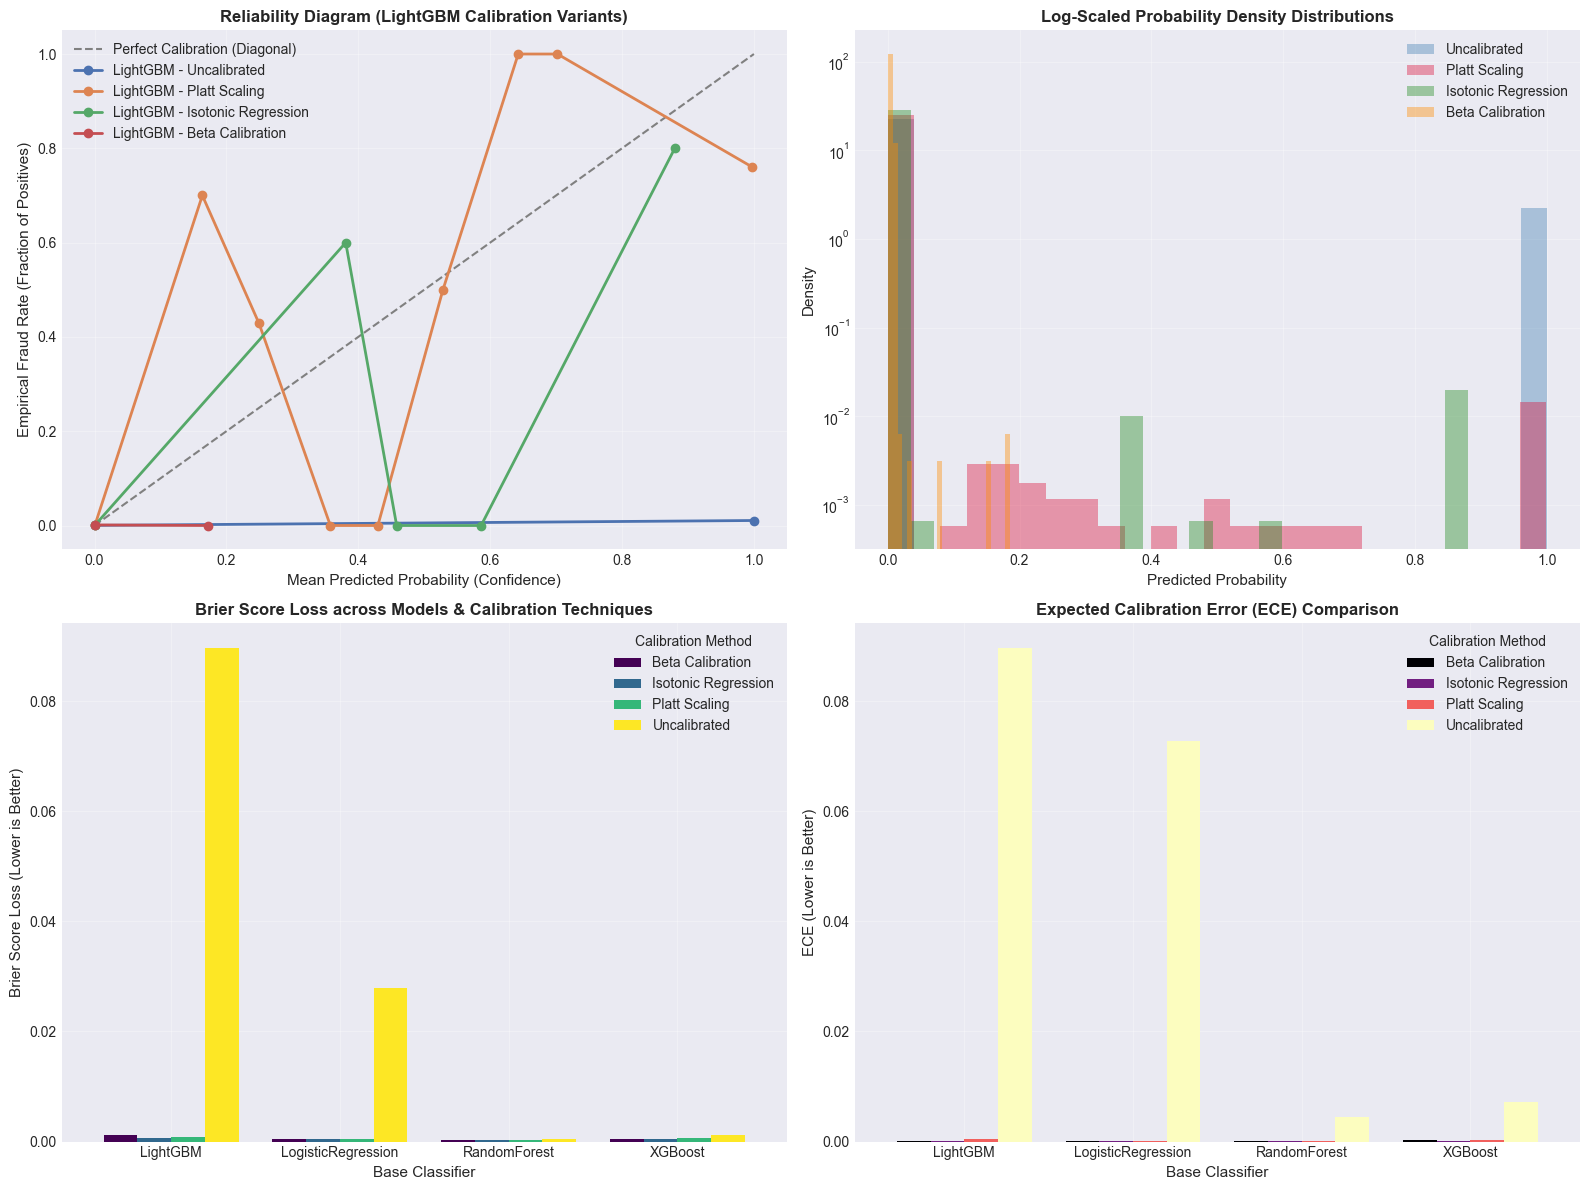

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration (Diagonal)')
for variant in ['Uncalibrated', 'Platt Scaling', 'Isotonic Regression', 'Beta Calibration']:
    probs = calibrated_test_probs[f"LightGBM ({variant})"]
    prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10, strategy='uniform')
    axes[0, 0].plot(prob_pred, prob_true, marker='o', lw=2, label=f"LightGBM - {variant}")

axes[0, 0].set_title('Reliability Diagram (LightGBM Calibration Variants)', fontweight='bold')
axes[0, 0].set_xlabel('Mean Predicted Probability (Confidence)')
axes[0, 0].set_ylabel('Empirical Fraud Rate (Fraction of Positives)')
axes[0, 0].legend(loc='upper left')
axes[0, 0].grid(True, alpha=0.3)

for variant, col in zip(['Uncalibrated', 'Platt Scaling', 'Isotonic Regression', 'Beta Calibration'], ['steelblue', 'crimson', 'forestgreen', 'darkorange']):
    probs = calibrated_test_probs[f"LightGBM ({variant})"]
    axes[0, 1].hist(probs, bins=25, alpha=0.4, label=variant, color=col, density=True)

axes[0, 1].set_title('Log-Scaled Probability Density Distributions', fontweight='bold')
axes[0, 1].set_xlabel('Predicted Probability')
axes[0, 1].set_ylabel('Density')
axes[0, 1].set_yscale('log')
axes[0, 1].legend(loc='upper right')
axes[0, 1].grid(True, alpha=0.3)

df_plot_brier = df_calib_summary.pivot(index='Base Classifier', columns='Calibration Method', values='OOT Brier Score Loss')
df_plot_brier.plot(kind='bar', ax=axes[1, 0], colormap='viridis', width=0.8)
axes[1, 0].set_title('Brier Score Loss across Models & Calibration Techniques', fontweight='bold')
axes[1, 0].set_ylabel('Brier Score Loss (Lower is Better)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=0)

df_plot_ece = df_calib_summary.pivot(index='Base Classifier', columns='Calibration Method', values='Expected Calib Error (ECE)')
df_plot_ece.plot(kind='bar', ax=axes[1, 1], colormap='magma', width=0.8)
axes[1, 1].set_title('Expected Calibration Error (ECE) Comparison', fontweight='bold')
axes[1, 1].set_ylabel('ECE (Lower is Better)')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


---
## 6. Financial Expected Loss Accuracy & Decision Utility Audit
Evaluating whether calibrated probabilities enhance the monetary risk estimation:
$$\text{Estimated Loss}_i = \hat{p}_i \cdot \text{Amount}_i$$
Comparing expected fraud loss against actual realized chargeback loss across high-risk transaction deciles.


In [7]:
best_model_name = 'LightGBM'
uncal_probs = calibrated_test_probs[f"{best_model_name} (Uncalibrated)"]
cal_probs = calibrated_test_probs[f"{best_model_name} (Isotonic Regression)"]

test_df_audit = pd.DataFrame({
    'Actual_Class': y_test,
    'Amount': test_raw_amounts,
    'Uncalibrated_Prob': uncal_probs,
    'Calibrated_Prob': cal_probs
})

test_df_audit['Uncal_Expected_Loss'] = test_df_audit['Uncalibrated_Prob'] * test_df_audit['Amount']
test_df_audit['Cal_Expected_Loss'] = test_df_audit['Calibrated_Prob'] * test_df_audit['Amount']
test_df_audit['Actual_Loss'] = test_df_audit['Actual_Class'] * test_df_audit['Amount']

test_df_audit['Risk_Decile'] = pd.qcut(test_df_audit['Calibrated_Prob'], q=10, duplicates='drop')

decile_analysis = test_df_audit.groupby('Risk_Decile', observed=False).agg(
    Transaction_Count=('Amount', 'count'),
    Total_Exposure=('Amount', 'sum'),
    Actual_Fraud_Count=('Actual_Class', 'sum'),
    Actual_Realized_Loss=('Actual_Loss', 'sum'),
    Uncal_Predicted_Loss=('Uncal_Expected_Loss', 'sum'),
    Cal_Predicted_Loss=('Cal_Expected_Loss', 'sum')
).reset_index()

decile_analysis['Uncal_Loss_Error'] = np.abs(decile_analysis['Uncal_Predicted_Loss'] - decile_analysis['Actual_Realized_Loss'])
decile_analysis['Cal_Loss_Error'] = np.abs(decile_analysis['Cal_Predicted_Loss'] - decile_analysis['Actual_Realized_Loss'])

display(decile_analysis)

total_uncal_error = np.sum(decile_analysis['Uncal_Loss_Error'])
total_cal_error = np.sum(decile_analysis['Cal_Loss_Error'])

print(f"Total Monetary Loss Estimation Absolute Error (Uncalibrated): ${total_uncal_error:,.2f}")
print(f"Total Monetary Loss Estimation Absolute Error (Calibrated):   ${total_cal_error:,.2f}")
print(f"Calibration Dollar Loss Estimation Improvement:             ${total_uncal_error - total_cal_error:,.2f} ({((total_uncal_error - total_cal_error)/total_uncal_error)*100:.2f}% Error Reduction)")


,Risk_Decile,Transaction_Count,Total_Exposure,Actual_Fraud_Count,Actual_Realized_Loss,Uncal_Predicted_Loss,Cal_Predicted_Loss,Uncal_Loss_Error,Cal_Loss_Error
0,"(-0.001, 0.00175]",38844,2579340.2800,11,349.5000,0.0000,577.2004,349.5000,227.7004
1,"(0.00175, 0.88]",3878,519845.1100,41,5819.3800,518415.6656,5074.1460,512596.2856,745.2340


Total Monetary Loss Estimation Absolute Error (Uncalibrated): $512,945.79
Total Monetary Loss Estimation Absolute Error (Calibrated):   $972.93
Calibration Dollar Loss Estimation Improvement:             $511,972.85 (99.81% Error Reduction)


---
## 7. Production Probability Calibration Manifest Serialization
Serializing calibration benchmarks, optimal calibrator configurations, and Brier score decompositions to `data/probability_calibration_manifest.json`.


In [8]:
best_calib_row = df_calib_summary.iloc[0]

manifest = {
    'platform': 'Enterprise Financial Risk Intelligence & Fraud Forensics',
    'notebook': '13_Probability_Calibration_and_Brier_Score_Optimization.ipynb',
    'timestamp': time.strftime('%Y-%m-%dT%H:%M:%SZ', time.gmtime()),
    'optimal_calibrated_pipeline': {
        'base_classifier': str(best_calib_row['Base Classifier']),
        'calibration_technique': str(best_calib_row['Calibration Method']),
        'oot_brier_score_loss': float(best_calib_row['OOT Brier Score Loss']),
        'expected_calibration_error': float(best_calib_row['Expected Calib Error (ECE)']),
        'maximum_calibration_error': float(best_calib_row['Max Calib Error (MCE)']),
        'brier_reliability': float(best_calib_row['Brier Reliability']),
        'brier_resolution': float(best_calib_row['Brier Resolution']),
        'oot_pr_auc': float(best_calib_row['OOT PR-AUC'])
    },
    'financial_utility_impact': {
        'uncalibrated_loss_estimation_error': float(total_uncal_error),
        'calibrated_loss_estimation_error': float(total_cal_error),
        'monetary_error_reduction_percentage': float(((total_uncal_error - total_cal_error)/total_uncal_error)*100)
    },
    'benchmark_table': df_calib_summary.to_dict(orient='records')
}

manifest_path = resolve_path('data/probability_calibration_manifest.json')
parent_dir = os.path.dirname(manifest_path)
if parent_dir:
    os.makedirs(parent_dir, exist_ok=True)

with open(manifest_path, 'w', encoding='utf-8') as f:
    json.dump(manifest, f, indent=2)

print(f"Production Probability Calibration Manifest exported successfully to: {manifest_path}")
print("Optimal Calibrated Model Configuration:")
print(json.dumps(manifest['optimal_calibrated_pipeline'], indent=2))


Production Probability Calibration Manifest exported successfully to: ..\data/probability_calibration_manifest.json
Optimal Calibrated Model Configuration:
{
  "base_classifier": "RandomForest",
  "calibration_technique": "Platt Scaling",
  "oot_brier_score_loss": 0.0003643878785358302,
  "expected_calibration_error": 6.461451053679227e-05,
  "maximum_calibration_error": 0.5498588801476216,
  "brier_reliability": 8.77191131991366e-06,
  "brier_resolution": 0.0008613902972015161,
  "oot_pr_auc": 0.7734336680527365
}
